## Your API key (30 seconds)

The course model runs on OpenRouter. Either add a Colab secret named `OPENROUTER_API_KEY` (key icon
in the left sidebar, *Notebook access* on), or run the cell below and paste the key when asked.

No key? Press Enter: the notebook switches to the mock model and everything still runs. Never paste
a key into a code cell — notebooks get shared.

In [ ]:
# === Setup: run this cell first ===============================================
# It reads your API key, creates the client, and defines chat(): the ONE function
# every section of this notebook uses to talk to the model.
import json, os, re
from getpass import getpass

MODEL = "openai/gpt-oss-120b"          # the course model on OpenRouter

def load_api_key():
    """Look for the key in Colab Secrets, then the environment, then ask once."""
    try:
        from google.colab import userdata           # only exists on Colab
        key = userdata.get("OPENROUTER_API_KEY")
        if key:
            return key, "Colab secret"
    except Exception:
        pass                                        # not on Colab, or no secret yet
    if os.getenv("OPENROUTER_API_KEY"):
        return os.environ["OPENROUTER_API_KEY"], "environment variable"
    try:
        key = getpass("OpenRouter API key (press Enter to use the mock model): ").strip()
    except Exception:                               # no keyboard available (automated run)
        key = ""
    return (key, "typed in") if key else ("", "none")

API_KEY, KEY_SOURCE = load_api_key()
LIVE = bool(API_KEY)                                # True = real model, False = mock model
client = None
if LIVE:
    from openai import OpenAI                       # the OpenAI SDK speaks OpenRouter's API too
    client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=API_KEY)

def chat(messages, tools=None, response_format=None, temperature=0.0, max_tokens=600):
    """Send ONE request to the model and return a plain dict:
         {"content": str, "tool_calls": [{"id", "name", "arguments"}], "usage": {...}}
    Everything else in this notebook is built on top of this function."""
    if not LIVE:
        return mock_model(messages, tools, response_format)
    request = dict(model=MODEL, messages=messages, temperature=temperature, max_tokens=max_tokens,
                   extra_body={"reasoning": {"effort": "low"}})   # keep hidden reasoning short and cheap
    if tools:
        request["tools"] = tools
    if response_format:
        request["response_format"] = response_format
    response = client.chat.completions.create(**request)
    message = response.choices[0].message
    calls = [{"id": call.id, "name": call.function.name,
              "arguments": json.loads(call.function.arguments or "{}")}
             for call in (message.tool_calls or [])]
    usage = response.usage
    return {"content": message.content or "", "tool_calls": calls,
            "usage": {"prompt_tokens": usage.prompt_tokens, "completion_tokens": usage.completion_tokens,
                      "total_tokens": usage.total_tokens}}

print("Model  :", MODEL)
print("Key    :", KEY_SOURCE)
print("Mode   :", "LIVE - real model replies" if LIVE else "MOCK - canned replies, real shapes, zero cost")

### The mock model (read later, or never)

This mock has no canned answers: it **reads the evidence the application supplied**, quotes the
passage matching the most specific words of the question, and abstains when none matches. It also
requests the retrieval tool when one is offered, and returns schema-shaped JSON when asked. It uses
`content_terms` from 2.2 — so run the notebook in order.

In [ ]:
ABSTAIN_TEXT = "The supplied documents do not contain enough evidence to answer this question."

def _mock_reply(content="", calls=None):
    return {"content": content, "tool_calls": calls or [],
            "usage": {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}}

def _mock_question(messages):
    """The original question: the first user message, minus any evidence wrapper around it."""
    text = next((m["content"] for m in messages if m["role"] == "user"), "")
    match = re.search(r"Question:\s*(.+)", text)
    return match.group(1).strip() if match else text.strip()

def _mock_evidence(messages):
    """Recover the labelled evidence blocks WE supplied: from a tool result, or from the prompt."""
    text = ""
    for message in reversed(messages):                       # a tool result is the freshest evidence
        if message["role"] == "tool":
            text = message["content"]
            break
    if not text:
        first_user = next((m["content"] for m in messages if m["role"] == "user"), "")
        text = first_user.split("Evidence:\n", 1)[-1] if "Evidence:\n" in first_user else ""
    passages = []
    for block in text.strip().split("\n\n"):                 # one block per chunk: label line + text
        if not block.startswith("[") or "]" not in block or "\n" not in block:
            continue
        label, _, body = block.partition("\n")
        fields = [part.strip() for part in label[label.index("]") + 1:].split(" | ")]
        passages.append({"chunk_id": label[1:label.index("]")], "source": fields[0],
                         "title": fields[1] if len(fields) > 2 else "",
                         "section": fields[-1], "text": body})
    return passages

def _mock_pick(question, passages):
    """The passage sharing the most SPECIFIC question words, or None when nothing matches.

    A word found in every passage ("battery") proves nothing; a word found in only one
    ("hissing") points at a particular passage. Only those count - so a question the corpus
    cannot answer produces no match at all and the mock abstains honestly."""
    words = [content_terms(f"{p['title']} {p['section']} {p['text']}") for p in passages]
    specific = max(1, len(passages) // 2)                    # 3 passages -> a term may hit only 1
    scores = [0] * len(passages)
    for term in content_terms(question):
        hits = [i for i, bag in enumerate(words) if term in bag]
        if 1 <= len(hits) <= specific:
            for i in hits:
                scores[i] += 1
    if not passages or not max(scores):
        return None
    return passages[max(range(len(passages)), key=lambda i: (scores[i], -i))]

def mock_model(messages, tools=None, response_format=None):
    """A stand-in model: evidence in, grounded answer or abstention out. Real reply shapes."""
    tool_names = [t["function"]["name"] for t in (tools or [])]
    already_used = {call["function"]["name"] for m in messages if m["role"] == "assistant"
                    for call in m.get("tool_calls", [])}
    question = _mock_question(messages)

    # 1) A search tool is on the table and has not been used: ask for it (section 2.7).
    if "search_engineering_documents" in tool_names and "search_engineering_documents" not in already_used:
        return _mock_reply(calls=[{"id": "call_search_1", "name": "search_engineering_documents",
                                   "arguments": {"query": question, "top_k": 3}}])

    # 2) Answer from the supplied evidence, or abstain when none of it is specific enough.
    passages = _mock_evidence(messages)
    chosen = _mock_pick(question, passages)
    if response_format:                                      # a schema was requested: return that shape
        if chosen is None:
            return _mock_reply(json.dumps({"answer": ABSTAIN_TEXT, "citations": [], "abstained": True}))
        return _mock_reply(json.dumps({
            "answer": chosen["text"], "abstained": False,
            "citations": [{"source": chosen["source"], "section": chosen["section"],
                           "chunk_id": chosen["chunk_id"]}]}))
    if chosen is None:                                       # plain text, no schema (section 2.4)
        return _mock_reply(ABSTAIN_TEXT if passages else "No evidence was supplied, so there is nothing to quote.")
    return _mock_reply(f"{chosen['text']}\n\n(quoted from {chosen['source']} | {chosen['section']})")

print("mock model ready" + ("" if LIVE else " and active"))

### Carried over from Day 1

Four helpers from yesterday, reproduced once so nothing is re-explained: `make_strict` (used by the
answer contract in 2.5) and `make_tool` / `execute_tool_call` / `assistant_message` (the tool
machinery section 2.7 points at the retriever).

In [ ]:
from pydantic import BaseModel, Field, ValidationError

def make_strict(node):
    """Day 1: convert a Pydantic JSON schema into the strict form providers accept."""
    if isinstance(node, dict):
        if node.get("type") == "object" and "properties" in node:
            node["additionalProperties"] = False
            node["required"] = list(node["properties"].keys())
        for key in ("minItems", "maxItems", "minimum", "maximum", "default"):
            node.pop(key, None)
        for value in node.values():
            make_strict(value)
    elif isinstance(node, list):
        for item in node:
            make_strict(item)
    return node

def make_tool(name, description, function, arg_model):
    """Day 1: bundle schema (what the model sees), validator, and function (what we run)."""
    return {"name": name, "function": function, "arg_model": arg_model,
            "schema": {"type": "function", "function": {
                "name": name, "description": description,
                "parameters": make_strict(arg_model.model_json_schema())}}}

def execute_tool_call(call, tools):
    """Day 1: validate a model's tool request and run it. Returns the observation as text."""
    tool = tools.get(call["name"])
    if tool is None:
        return f"Tool error: unknown tool '{call['name']}'"
    try:
        arguments = tool["arg_model"].model_validate(call["arguments"])
        return tool["function"](**arguments.model_dump())
    except ValidationError as error:
        first = error.errors()[0]
        return f"Tool error: argument '{'.'.join(map(str, first['loc'])) or 'input'}' {first['msg']}"
    except (ValueError, KeyError) as error:
        return f"Tool error: {str(error).splitlines()[0]}"

def assistant_message(reply):
    """Day 1: turn a chat() reply into the message the API expects back in the history."""
    message = {"role": "assistant", "content": reply["content"]}
    if reply["tool_calls"]:
        message["tool_calls"] = [{"id": c["id"], "type": "function",
                                  "function": {"name": c["name"], "arguments": json.dumps(c["arguments"])}}
                                 for c in reply["tool_calls"]]
    return message

print("Carried over:", ", ".join(["make_strict", "make_tool", "execute_tool_call", "assistant_message"]))

### Create the day's data

Three short Markdown documents for a fictional campus microgrid, written next to the notebook so
2.1 ingests real files, plus ten golden questions whose evidence we already know. Small is
deliberate: every retrieval result can be checked by hand.

In [ ]:
from pathlib import Path

CORPUS_DIR = Path("day2_corpus")
CORPUS_DIR.mkdir(exist_ok=True)

DOCUMENTS = {
"solar_microgrid.md": """# Campus Solar Microgrid — Operating Notes

## Purpose

The campus microgrid combines rooftop solar photovoltaic generation, a battery energy storage system, controllable loads, and a grid connection. Its primary goals are to reduce peak grid demand, preserve critical services during short outages, and increase the fraction of locally consumed renewable energy.

## Operating modes

In grid-connected mode, the utility grid establishes voltage and frequency. The microgrid controller schedules battery charging when solar generation exceeds campus demand and may discharge the battery during the evening peak. Export to the utility is disabled in the teaching installation.

In islanded mode, the battery inverter establishes the local voltage and frequency. Only the critical-load panel remains energized. Laboratory air-conditioning and vehicle charging are disconnected automatically to prevent the islanded system from being overloaded.

## Transition conditions

The controller opens the point-of-common-coupling breaker after detecting utility voltage or frequency outside the permitted range for the configured protection interval. Before reconnecting, it verifies that utility voltage, frequency, and phase remain within synchronization limits for five continuous minutes.

## Load priorities

Priority 1 loads include emergency lighting, network equipment, fire-alarm equipment, and the medical room refrigerator. Priority 2 includes selected laboratory instruments. Priority 3 includes comfort cooling, water heating, and vehicle charging. Lower-priority loads are shed first.

## Limitation

The teaching microgrid is designed for short-duration resilience, not indefinite backup. Available islanding time depends on battery state of charge, critical-load demand, temperature, and battery power limits.
""",
"battery_safety.md": """# Lithium-Ion Battery System — Safety Guide

## Normal operating envelope

The battery-management system monitors cell voltage, pack current, and temperature. Charging is permitted only between 5 °C and 45 °C. Discharging is permitted between −10 °C and 50 °C. These thresholds are example values for the teaching system and must not be applied to another battery without its manufacturer documentation.

## Warning and shutdown

At 45 °C during charging, the controller stops charging and raises a high-temperature warning. At 55 °C, the system opens the battery contactor and reports a critical-temperature shutdown. The battery must not be returned to service until a qualified technician identifies the cause and completes the inspection checklist.

## Thermal event response

If smoke, rapid temperature rise, unusual odor, hissing, or enclosure deformation is observed, occupants must not open the battery cabinet. They must activate the site emergency procedure, isolate the area, notify emergency personnel, and follow the facility fire-response plan. This course document is not a substitute for manufacturer or emergency-service instructions.

## Inspection

A visual inspection is performed monthly. The inspection records enclosure damage, corrosion, warning indicators, blocked ventilation, cable damage, and evidence of liquid ingress. Insulation resistance and protective-device tests are performed during the scheduled annual service by qualified personnel.

## Data retention

The controller stores one-minute operating summaries for 30 days and fault-event records for one year. Fault records include the timestamp, measured values, active operating mode, and protection action.
""",
"controller_interface.md": """# Microgrid Controller — Interface Reference

## Telemetry

The controller exposes read-only telemetry for solar power, battery power, battery state of charge, grid import, critical-load demand, operating mode, and active alarms. Power values use kilowatts and state of charge uses percentage.

## Commands

The teaching API supports `set_battery_power_limit`, `request_island_mode`, and `acknowledge_alarm`. A positive battery power limit permits discharge; a negative value permits charging. The permitted magnitude is restricted by the current battery-management-system limits.

`request_island_mode` does not immediately open the grid breaker. It starts a validation sequence that checks battery state of charge, inverter readiness, protection status, and estimated critical-load demand. The controller rejects the request if any precondition fails.

## Authorization

Telemetry requires the `viewer` role. Changing a power limit requires the `operator` role. Requesting island mode requires the `operator` role and a second human confirmation. Protection settings cannot be changed through the teaching API.

## Errors

Errors use a structured object containing `code`, `message`, and `retryable`. Validation failures are not retryable until the input or system condition changes. Temporary communication failures may be retried twice with a delay. Repeating a rejected operational command without changing conditions is prohibited.

## Audit trail

Every command attempt records the user identifier, timestamp, requested action, validated arguments, authorization result, approval result, and final execution status. Read-only telemetry queries are aggregated rather than stored individually.
""",
}

for name, text in DOCUMENTS.items():
    (CORPUS_DIR / name).write_text(text, encoding="utf-8")

# The exam paper. It is never indexed and never shown to the model.
GOLDEN_CASES = [
    {"id": "q01", "question": "Which loads stay powered when the campus microgrid is islanded?",
     "answerable": True, "expected_source": "solar_microgrid.md", "expected_section": "Load priorities",
     "essential_terms": ["emergency lighting", "network equipment", "fire-alarm", "medical room refrigerator"]},
    {"id": "q02", "question": "What establishes voltage and frequency during islanded operation?",
     "answerable": True, "expected_source": "solar_microgrid.md", "expected_section": "Operating modes",
     "essential_terms": ["battery inverter"]},
    {"id": "q03", "question": "How long must synchronization remain acceptable before reconnection?",
     "answerable": True, "expected_source": "solar_microgrid.md", "expected_section": "Transition conditions",
     "essential_terms": ["five continuous minutes"]},
    {"id": "q04", "question": "At what temperature does charging stop with a warning?",
     "answerable": True, "expected_source": "battery_safety.md", "expected_section": "Warning and shutdown",
     "essential_terms": ["45 °C", "stops charging"]},
    {"id": "q05", "question": "What should occupants do if the battery cabinet is hissing?",
     "answerable": True, "expected_source": "battery_safety.md", "expected_section": "Thermal event response",
     "essential_terms": ["must not open", "isolate", "emergency"]},
    {"id": "q06", "question": "For how long are battery fault-event records retained?",
     "answerable": True, "expected_source": "battery_safety.md", "expected_section": "Data retention",
     "essential_terms": ["one year"]},
    {"id": "q07", "question": "Which role can read controller telemetry?",
     "answerable": True, "expected_source": "controller_interface.md", "expected_section": "Authorization",
     "essential_terms": ["viewer"]},
    {"id": "q08", "question": "Does requesting island mode immediately open the grid breaker?",
     "answerable": True, "expected_source": "controller_interface.md", "expected_section": "Commands",
     "essential_terms": ["does not immediately", "validation sequence"]},
    {"id": "q09", "question": "What information is recorded for each controller command attempt?",
     "answerable": True, "expected_source": "controller_interface.md", "expected_section": "Audit trail",
     "essential_terms": ["user identifier", "timestamp", "authorization", "execution status"]},
    {"id": "q10", "question": "What is the purchase price of the battery system?",
     "answerable": False, "expected_source": None, "expected_section": None, "essential_terms": []},
]

print("corpus folder :", CORPUS_DIR.resolve())
print("documents     :", [path.name for path in sorted(CORPUS_DIR.glob("*.md"))])
print("golden cases  :", len(GOLDEN_CASES), "->", sum(case["answerable"] for case in GOLDEN_CASES),
      "answerable,", sum(not case["answerable"] for case in GOLDEN_CASES), "unanswerable")

# Day 2.1 — Documents and Chunks
The model has never seen these documents and never will: nothing today trains anything. First the
files must become small labelled pieces a retriever can rank and a citation can point at.

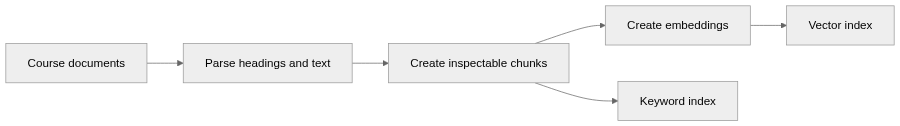

*D06 — documents are parsed into inspectable chunks, which are embedded into an index*

### Step 1 — Read the documents, and price the lazy option

Never index something you have not read — and measure the lazy option (paste all three documents
into every request) before rejecting it.

In [ ]:
files = sorted(CORPUS_DIR.glob("*.md"))            # sorted so the order is the same on every machine
for path in files:
    lines = path.read_text(encoding="utf-8").splitlines()
    headings = [line[3:] for line in lines if line.startswith("## ")]
    print(f"{path.name:26} {path.stat().st_size:>5} bytes  {len(headings)} sections -> {headings}")

words = len("\n".join(path.read_text(encoding="utf-8") for path in files).split())
print()
print("whole corpus      :", words, "words  (~", int(words / 0.75), "tokens; English is ~0.75 words per token)")
print("a typical question:", len("How long are battery fault records retained?".split()), "words")
print("So >99% of what we would send is irrelevant to any one question - and paid for every time.")

### Step 2 — Split by heading into chunks

A whole document matches every question a little and none precisely; a single sentence loses the
condition that gives it meaning. The `##` section is a good middle, and each chunk keeps the
metadata a citation quotes.

In [ ]:
class Chunk(BaseModel):
    """One retrieval unit. The metadata matters as much as the text."""
    chunk_id: str          # stable id such as battery_safety:data-retention
    source: str            # file name, for the citation
    title: str             # document title
    section: str           # heading this text sat under
    text: str

    @property
    def searchable_text(self) -> str:
        """What the retriever indexes: heading words help a query find the right section."""
        return f"{self.title}\n{self.section}\n{self.text}"

def slug(value):
    return re.sub(r"[^a-z0-9]+", "-", value.lower()).strip("-")

def chunk_markdown(path):
    """One chunk per second-level (`##`) section of one Markdown file."""
    title, section, buffer, chunks = path.stem.replace("_", " ").title(), "Introduction", [], []

    def flush():
        text = " ".join(line.strip() for line in buffer if line.strip()).strip()
        if text:
            chunks.append(Chunk(chunk_id=f"{path.stem}:{slug(section)}", source=path.name,
                                title=title, section=section, text=text))

    for line in path.read_text(encoding="utf-8").splitlines():
        if line.startswith("# "):                      # document title
            title = line[2:].strip()
        elif line.startswith("## "):                   # a new section starts: close the previous one
            flush()
            buffer, section = [], line[3:].strip()
        else:
            buffer.append(line)
    flush()
    return chunks

def load_corpus(directory):
    return [chunk for path in sorted(Path(directory).glob("*.md")) for chunk in chunk_markdown(path)]

chunks = load_corpus(CORPUS_DIR)
print("chunks created:", len(chunks), "\n")
print(f"{'chunk_id':42}{'source':24}{'section':30}chars")
print("-" * 102)
for chunk in chunks:
    print(f"{chunk.chunk_id:42}{chunk.source:24}{chunk.section:30}{len(chunk.text)}")

# One chunk in full: these five fields are exactly what a citation will quote.
target = next(chunk for chunk in chunks if "five continuous minutes" in chunk.text)
print("\nONE CHUNK IN FULL")
for field in ("chunk_id", "source", "title", "section"):
    print(f"  {field:9}:", getattr(target, field))
print("  text     :", target.text)
print("  indexed  :", repr(target.searchable_text[:90]) + " ...")

### Step 3 — Break it: blind character slices

Chunking is not "cut every N characters". Slice the same file every 250 characters: the pieces have
no source, section or id, and the reconnection rule is split across two of them.

In [ ]:
raw = (CORPUS_DIR / "solar_microgrid.md").read_text(encoding="utf-8")
slices = [raw[start:start + 250] for start in range(0, len(raw), 250)]
rule = "utility voltage, frequency, and phase remain within synchronization limits for five continuous minutes"

print("blind slices:", len(slices), "- each carries no source, no section, no id")
for number, piece in enumerate(slices, start=1):
    if "five continuous minutes" in piece:
        print(f"  slice {number} ends: ...{piece[-60:]!r}")
print()
print("whole rule inside ONE blind slice   :", any(rule in piece for piece in slices))
print("whole rule inside ONE heading chunk :", any(rule in chunk.text for chunk in chunks))

### Try it yourself

The battery guide mentions `45 °C`. Predict how many chunks contain it, then run the cell. Would
retrieving *any* of them answer "at what temperature does charging stop?"

In [ ]:
# --- Worked solution ---------------------------------------------------------------
matches = [chunk for chunk in chunks if "45 °C" in chunk.text]
print("chunks containing '45 °C':", len(matches))
for chunk in matches:
    print(f"  {chunk.chunk_id:42} {chunk.text[:95]} ...")
print()
print("Both sections mention 45 degrees; only 'Warning and shutdown' says what HAPPENS there.")
print("Retrieval must pick the right SECTION, not just the right file - which is why section 2.6")
print("scores section hits and not only source hits.")

### Checkpoint

**1. Why does a chunk store `source` and `section` instead of only text?**

<details><summary>Show answer</summary>

Everything downstream needs provenance: a citation names a file and a section, evaluation compares retrieved section with expected, and debugging asks which document a sentence came from. Text alone answers none of those.

</details>

**2. We produced 15 chunks. Why not 3, one per document?**

<details><summary>Show answer</summary>

A whole document matches every question a little and none precisely, so ranking stops meaning anything. One sentence per chunk goes too far the other way and drops the surrounding condition.

</details>

### Recap

- **Limitation seen:** whole documents are too expensive to send; blind slices destroy meaning and metadata.
- **Layer added:** heading-aware chunking keeping `source`, `title`, `section` and a stable `chunk_id`.
- **Evidence:** 15 labelled chunks, and the five-minute rule survives intact in exactly one of them.